# Custom Image Classification using Vision Transformer

This dataset contains 3 classes pizza, steak and sushi. We are going to create image classification model to classify these images. 

In [28]:
# Import libraries
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms

from src.utils.utils import get_device
from src.data.data_setup import create_dataloaders
from src.model.transformer import build_transformer
from src.train.training import train_model

In [2]:
# Initialize model and training parameters
train_dir = 'data/train'
val_dir = 'data/val'

# Transforms to be performed on the input images
list_of_transforms = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

# Input image dimensions
in_image_height=112
in_image_width=112
in_color_channels=3

# Size of embedding vector
d_model=768
# Individual patch size
patch_size=8
# No. of patches from the image
no_of_patches = int((in_image_height*in_image_width) / (patch_size*patch_size)) + 1
# number of encoder blocks
num_layers = 4
# number of attention heads
num_heads = 8
# Number of hidden nodes for feed-forward layer
d_ff = 4*d_model
# Dropout factor
dropout = 0.1

# Number of epochs
epochs = 15
# Batch size for training
batch_size = 32

In [3]:
# Get a device to use for training/inference
device = get_device()

# Create training and validation data loaders
train_dataloader, val_dataloader, class_names = create_dataloaders(train_dir, val_dir, list_of_transforms, 
                                                                   list_of_transforms, batch_size)

Random image path: data/train/shoe/Shoe (3896).jpg
Image class: shoe
Image height: 102
Image width: 136


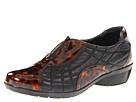

In [4]:
# Load and observe random image

import random
from PIL import Image
from pathlib import Path

data_path = Path('data/')
image_path = data_path / 'train'

# Get all image paths (* means "any combination")
image_path_list = list(image_path.glob("*/*.jpg"))

# Get random image path
random_image_path = random.choice(image_path_list)

# Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

In [5]:
# Create encoder only transformer model
vision_transformer_model = build_transformer(in_color_channels, d_model, patch_size, no_of_patches, dropout, 
                                             num_layers, num_heads, d_ff, len(class_names)).to(device)

print(vision_transformer_model)

Transformer(
  (embed): PatchEmbedding(
    (patcher): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
    (flatten): Flatten(start_dim=2, end_dim=3)
  )
  (pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-3): 4 x EncoderBlock(
        (self_attention): MultiHeadAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (query_linear_layer): Linear(in_features=768, out_features=768, bias=True)
          (key_linear_layer): Linear(in_features=768, out_features=768, bias=True)
          (value_linear_layer): Linear(in_features=768, out_features=768, bias=True)
          (output_linear_layer): Linear(in_features=768, out_features=768, bias=True)
        )
        (feed_forward): FeedForward(
          (linear_1): Linear(in_features=768, out_features=3072, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear_2): Linear(in_features=3072, out_features=768, bias=True)
 

In [6]:
# Create optimizer and loss function
optimizer = torch.optim.Adam(
    vision_transformer_model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    weight_decay=1e-4
)
loss_fn = nn.CrossEntropyLoss()

# Train model
train_model(epochs, len(class_names), vision_transformer_model, train_dataloader, val_dataloader,
            loss_fn, optimizer, device)

Epoch 1, Train Loss 1.2773959636688232, Train Accuracy 0.32892897725105286, Validation Loss 1.1040399074554443, Validation Accuracy 0.332446813583374
Epoch 2, Train Loss 1.1275209188461304, Train Accuracy 0.34343263506889343, Validation Loss 0.7945603132247925, Validation Accuracy 0.6296542286872864
Epoch 3, Train Loss 0.6747108101844788, Train Accuracy 0.6956034302711487, Validation Loss 0.4773593246936798, Validation Accuracy 0.8066109418869019
Epoch 4, Train Loss 0.44807276129722595, Train Accuracy 0.8259457349777222, Validation Loss 0.43538880348205566, Validation Accuracy 0.8352963924407959
Epoch 5, Train Loss 0.41330572962760925, Train Accuracy 0.8406292796134949, Validation Loss 0.43425917625427246, Validation Accuracy 0.8444148898124695
Epoch 6, Train Loss 0.38253864645957947, Train Accuracy 0.8518534302711487, Validation Loss 0.40817317366600037, Validation Accuracy 0.8490691781044006
Epoch 7, Train Loss 0.36908823251724243, Train Accuracy 0.8558733463287354, Validation Loss 0

In [8]:
# Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save path
MODEL_NAME = "09_vision_transformer_image_classification.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

In [10]:
# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=vision_transformer_model.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/09_vision_transformer_image_classification.pth


In [33]:
# Download model from here and save it to the models directory (Since Github doesn't store large files)
# Download link: https://drive.google.com/file/d/1zGMWs7QnbIgZS28Q6n1z4Bs1xRG1bG0_/view?usp=sharing

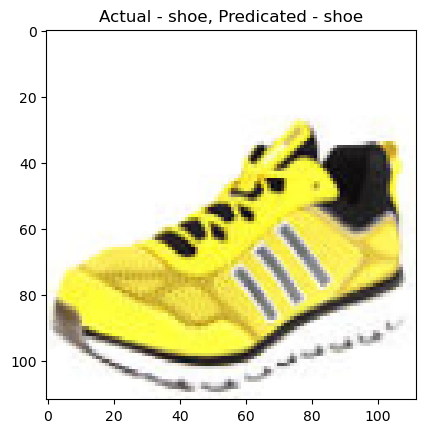

In [32]:
# Load and predict using Vision Transformer model
loaded_model = build_transformer(in_color_channels, d_model, patch_size, no_of_patches, dropout, 
                                             num_layers, num_heads, d_ff, len(class_names)).to(device)
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model.to(device)

test_transforms = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=test_transforms,
    target_transform=None
)

random_index = torch.randint(0, len(test_dataset), (1,)).item()
image, label = test_dataset[random_index]
image = image.to(device)

loaded_model.eval()
with torch.inference_mode():
    encoder_output = loaded_model.encode(image.unsqueeze(dim=0))
    y_logits = loaded_model.project(encoder_output)
    predicted_label = torch.argmax(y_logits, dim=1)
    
plt.title(f'Actual - {class_names[label]}, Predicated - {class_names[predicted_label.item()]}')
plt.imshow(image.cpu().permute(1, 2, 0))